In [4]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append("..")

In [6]:
import torch
import torch.fft
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

import numpy as np

import time

import random

import soap
from architectures import PINO1D
from generators import SlabWaveguideDataset
from utils import analytical_solution, solve_fd_mode

## Slab Waveguide training utilities

In [22]:
def second_derivative_centered(f, x):
    """
    f: (B, 1, N) tensor
    dx: grid spacing (scalar)
    Returns: second derivative ∂²f/∂x² with same shape
    """
    d2fdx2 = torch.zeros_like(f)

    e = x[:, :, 2:] - x[:, :, 1:-1]
    w = x[:, :, 1:-1] - x[:, :, :-2]

    dividend = 2/(e+w)
    
    d2fdx2[:, :, 1:-1] = (dividend * f[:, :, 2:]/e - 2 * f[:, :, 1:-1]/(e*w) + dividend * f[:, :, :-2]/w)
    d2fdx2[:, :, 0] = d2fdx2[:, :, 1]     # replicate boundary
    d2fdx2[:, :, -1] = d2fdx2[:, :, -2]

    return d2fdx2

def second_TM_derivative_centered(f, x, r):
    """
    f: (B, 1, N) tensor
    dx: grid spacing (scalar)
    Returns: second derivative ∂²f/∂x² with same shape
    """
    d_term = torch.zeros_like(f)

    e = x[:, :, 2:] - x[:, :, 1:-1]
    w = x[:, :, 1:-1] - x[:, :, :-2]

    term1 = (1/e)*((r[:, :, 2:] - r[:, :, 1:-1])/(r[:, :, 2:] + r[:, :, 1:-1]))*(f[:, :, 2:] + f[:, :, 1:-1])
    term2 = (1/w)*((r[:, :, 1:-1] - r[:, :, :-2])/(r[:, :, 1:-1] + r[:, :, :-2]))*(f[:, :, 1:-1] + f[:, :, :-2])

    d_term[:, :, 1:-1] = (2/(e+w)) * (term1 - term2)
    d_term[:, :, 0] = d_term[:, :, 1]     # replicate boundary
    d_term[:, :, -1] = d_term[:, :, -2]

    return d_term


def helmholtz_residual_loss(selected_indices, x, E, ri,features, beta, weight=1):
    """
    E:   (B, 1, N) predicted electric field
    ri:  (B, 1, N) refractive index profile
    k0:  free-space wavenumber (default: λ=1.55 μm)
    beta: None or tensor of shape (B,) — will be estimated if None
    Returns: scalar loss
    """
    B, _, N = E.shape
    n2 = ri
    k0 = features[:, [0]]

    # Get top 2 values along spatial dimension
    n2_max = features[:, [-2]]  # (B, 1)
    n2_min = torch.minimum(features[:, [-3]], features[:, [-4]])  # (B, 1)

    beta_sq = (n2_max - beta * (n2_max - n2_min)) * k0**2  # (B, 1)
    
    d2E1 = second_TM_derivative_centered(E, x, ri)
    d2E1[selected_indices==1] = 0
    d2E2 = second_derivative_centered(E, x)

    residual = d2E1 + d2E2 + (k0.unsqueeze(-1)**2 * n2 - beta_sq.unsqueeze(-1)) * E
    loss = (residual**2).mean()
    beta_loss = (beta**2).mean() * weight
    return loss, beta_loss, beta_sq, n2_max * k0**2

def boundary_condition_loss(E):
    """
    E: (B, 1, N)
    Penalizes non-zero values at the domain edges.
    """
    left = E[:, :, 0]
    right = E[:, :, -1]
    return (left ** 2 + right ** 2).mean()

In [23]:
def train(loader, val_loader, model, optimizer, scheduler, epochs, load, save):
    train_loss_history = []
    val_loss_history = []
    betas_avg = []
    xyr_val, features_val = next(iter(val_loader))

    epoch = 0
    checkpoint_no = 0
    if load:
        checkpoint_no = np.load('model_checkpoints/last_checkpoint.npy').item()
        checkpoint = torch.load(f"model_checkpoints/slab_full_checkpoint_{checkpoint_no}.pth", weights_only=False)
        
        epoch = checkpoint["epoch"] + 1
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        
        train_loss_history = checkpoint["train_loss_history"]
        val_loss_history = checkpoint["val_loss_history"]
        betas_avg = checkpoint["betas_avg"]
        
        if checkpoint.get('xyr_val', None) is not None: 
            xyr_val = checkpoint['xyr_val'].to(device)
            features_val = checkpoint['features_val'].to(device)
        print('loaded latest parameteres')

    analytical_EIs = np.zeros(len(xyr_val))
    dx = val_loader.dataset.dx
    
    for iteration_no in range(epoch+1, epochs):
        weight = 1e2 * max(0, 1-iteration_no/1000)
        for (i, (xyr, features)) in enumerate(loader):
            E_out, beta = model(xyr)                 # (B, 1, N)
            x = xyr[:, 0:1, :]           #  (B, 1, N)
            ri = xyr[:, 1:2, :]            # (B, 1, N)
            selected_indices = features[:, -1].to(torch.int)
            E = E_out/torch.sqrt(dx*torch.sum(E_out**2, dim=-1, keepdim=True))
            
            bc_loss = boundary_condition_loss(E)
            helm_loss, beta_loss, beta, n2_max = helmholtz_residual_loss(selected_indices, x, E, ri, features, beta, weight)
            
            loss = helm_loss + bc_loss + beta_loss * weight

            train_loss_history.append(helm_loss.item() + bc_loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        scheduler.step()

        if (iteration_no + 1) % 250 == 0:
            print(f"Epoch {iteration_no}:")
            print(f"  β² prediction ≈ {beta.squeeze().detach().cpu().numpy()}")
            print(f"  β² max ≈ {n2_max.squeeze().detach().cpu().numpy()}")
    
            print(f"Physics Loss: {helm_loss.item():.6e}  Total Loss: {loss.item():.6e}")

            if (iteration_no + 1) % 1000==0:
                plt.plot(E[0, 0].cpu().detach())
                plt.show()


            with torch.no_grad():
                E_out, eta = model(xyr_val)
                
            x = xyr_val[:, 0:1, :]           #  (B, 1, N)
            ri = xyr_val[:, 1:2, :]            # (B, 1, N)
            selected_indices = features_val[:, -1].to(torch.int)
            E = E_out/torch.sqrt(dx*torch.sum(E_out**2, dim=-1, keepdim=True))

            bc_loss = boundary_condition_loss(E)
            helm_loss, beta_loss, beta, n2_max = helmholtz_residual_loss(selected_indices, x, E, ri, features_val, eta, weight)

            val_loss_history.append(helm_loss.item()  + bc_loss.item())

            n2_max = features_val[:, -2]
            n2_min = torch.minimum(features_val[:, -4], features_val[:, -3])  # (B, 1)
            
            n_cladding = torch.sqrt(features_val[:, -4])
            n_substrate = torch.sqrt(features_val[:, -3])
            n_core= torch.sqrt(features_val[:, -2])
            w_core= features_val[:, 1]
            k0 =  features_val[:, 0]
            TE = features_val[:, -1]
        
            betas_sq = (n2_max - eta.squeeze() * (n2_max - n2_min))
        
            betas_avg.append(torch.mean(betas_sq).item())

            if analytical_EIs[0] < 1e-5:
                for i in range(len(xyr_val)):
                    x_out = xyr_val[i, 0:1, :].cpu().squeeze()    # (N,)
                    analytical_modes, analytical_EI = analytical_solution(x_out.numpy(), n_core[i].item(), n_substrate[i].item(), n_cladding[i].item(), w_core[i].item(), k0[i].item(), TE[i]==0)
                    analytical_EIs[i] = analytical_EI**2


        if (iteration_no + 1) % 500 == 0 and (iteration_no + 1) in [5000, 8500, 10000] and  save:
            model.to('cpu')
            checkpoint = {
                "epoch": iteration_no,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "train_loss_history": train_loss_history,
                "val_loss_history": val_loss_history,                
                'analytical_EIs.npy': analytical_EIs,
                "betas_avg": betas_avg,
                'xyr_val' : xyr_val.cpu(),
                'features_val' : features_val.cpu()
            }
            torch.save(checkpoint, f"model_checkpoints/slab_full_checkpoint_{checkpoint_no}.pth")
            np.save('last_checkpoint.npy', checkpoint_no)
            checkpoint_no += 1
            model.to(device)
            
    return model, betas_avg, analytical_EIs, train_loss_history, val_loss_history

In [11]:
torch.manual_seed(42);

In [12]:
device = 'cuda'

In [13]:
dataset = SlabWaveguideDataset(dx = 1/20, stochastic=True, n_dataset=64, x_range=(-5.0, 5.0), device=device)
loader = DataLoader(dataset, batch_size=64, shuffle=False)

val_ds = SlabWaveguideDataset(dx = 1/20, stochastic=True, n_dataset=1024, x_range=(-5.0, 5.0), device=device)
val_loader = DataLoader(val_ds, batch_size=1024, shuffle=False)

In [14]:
# Setup
model = PINO1D(4, 1, 64, 32, 4).to(device)

In [15]:
optimizer = soap.SOAP(model.parameters())
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[5000, 8500], gamma=1e-1)

Epoch 249:
  β² prediction ≈ [175.7727   181.52673  188.82822  176.63148  182.70055  141.43738
 171.63039  264.9738    40.361893 244.36081  257.72772  174.66724
 163.68657  188.62463   21.929361 121.23489   66.82905  375.0948
 206.798    215.44458   38.45991   87.42788   32.52774  210.52444
 329.45294  304.01578   54.907597 108.2766    39.43992   54.168743
  68.98522  344.4415   389.67596  153.31133  109.43852  148.13701
  51.933643 103.01398   86.72611  226.99069  118.588905  51.074932
  68.76726  163.03703  172.24634   36.009068  72.71724   73.18358
  47.297947 434.59485  118.81211   81.61624  238.91757  169.47585
 456.70428   74.413635 374.68082  100.02042  107.27414  164.12915
  64.81447  177.88802  226.78938  137.58745 ]
  β² max ≈ [175.7727   181.52676  188.82823  176.63152  182.70058  141.43765
 171.63042  264.9738    40.36278  244.36082  257.72772  174.66727
 163.6866   188.62471   21.929983 121.23496   66.82935  375.0948
 206.79807  215.44458   38.46022   87.428055  32.528    

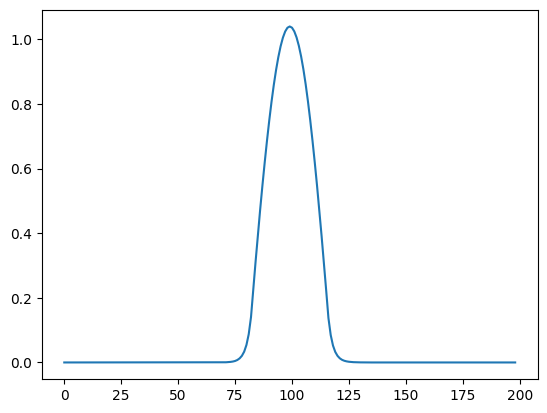

Epoch 1249:
  β² prediction ≈ [ 76.41449  191.28938  167.5233   172.1281    83.23601  242.24684
 125.209694  49.89972  278.42752   97.703125  78.56744  155.97536
 138.58092  416.608    158.75507   44.5817   128.7759    76.362144
 127.78324   52.76584   80.98832  228.66905  147.25877   69.700775
 123.85186   41.398643  45.70482   85.84344   86.89026  104.72322
 130.62405   24.964542 114.48444   51.73596  288.70877  216.56747
  44.808594  75.0408    62.360466 104.97806  164.13864  150.72852
 126.469765 170.67516  276.4171    49.47449   42.52103  184.60477
  74.610146 143.50833  392.4178   139.5344   317.41977  162.33583
  83.65616  139.01566  170.60197   96.34789  106.306366  78.39674
  53.81907  135.9971   107.28132  162.51367 ]
  β² max ≈ [ 78.798    194.4091   171.60771  175.12894   89.1608   245.58098
 129.83138   52.513824 281.4547   103.69824   80.91424  159.81546
 142.64915  420.36392  161.10736   46.77749  133.10565   78.28201
 130.7453    55.31686   83.22355  236.29541  149.8461

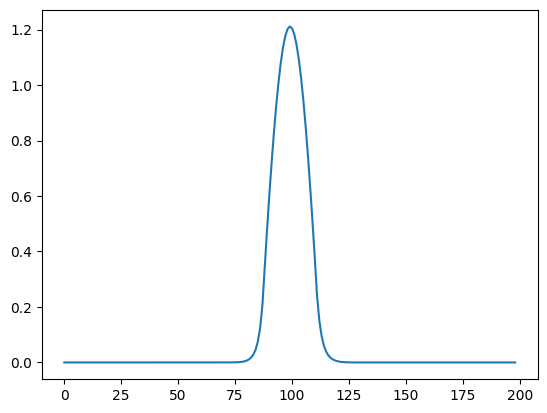

Epoch 2249:
  β² prediction ≈ [231.75583   33.536613 372.1166   168.39084  101.98339  168.04794
  21.677961 169.80634   68.60064  379.6322    82.28985   66.11329
 197.16019  209.61317   96.9331    93.81862  157.06885  428.7346
 248.5727   124.512054 104.19946  128.27371  109.20282   35.525223
 105.89494  163.11964  339.53342  100.155914  51.92193   78.29729
 121.844284 242.54834  125.89781  128.45949   62.597797  71.9865
  47.18324  160.3321   150.92351   37.683975 148.09348  405.322
 230.2344   110.55004  209.60632  283.24628  155.11473  111.43337
 469.8258    49.8027    31.335629 107.917694  78.36495   98.6879
 118.9203    65.28302  150.914    159.2284    49.74939  161.13666
  56.929104 211.04877   91.00199  142.92816 ]
  β² max ≈ [234.83392   35.95209  375.20163  173.17715  107.10866  173.11862
  23.37119  176.66232   71.38985  383.61432   84.38799   69.428185
 199.81514  213.43109   98.9515    97.90844  165.11945  432.5452
 254.42047  129.43219  106.727036 135.978    111.62458   38

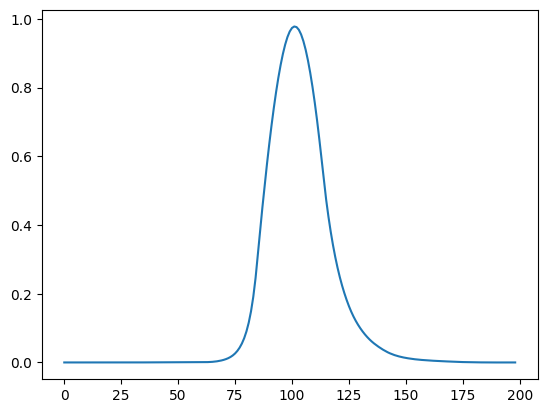

Epoch 3249:
  β² prediction ≈ [128.31078  160.73909  181.81229   35.740257 102.69016  148.09972
  64.732956 112.65824  119.720825 144.09003  128.92717   45.759686
 451.9246   166.31357  442.74115   49.967125 281.5843   132.70685
  65.17691  250.21869  181.22946   58.556015  41.14314   91.954
 132.41429   42.895287 174.94583   98.33526  109.44067   28.858011
 170.69708  227.90599  391.8607   178.3666    40.251595  80.37625
  48.475906 109.381905  69.42794  246.42664  278.60913  104.422905
  76.706375 103.520706 127.03937  137.16258  121.456474 359.42273
  73.7527   142.49832  116.84258  115.57407   67.825356  43.395103
 209.61903  444.91556   35.501957 132.66171   52.397865 183.28275
 131.2226    48.044315  70.02128   62.9102  ]
  β² max ≈ [132.19838  163.62183  185.65883   37.50404  105.634895 152.441
  66.3886   114.96439  123.41814  148.27333  131.7417    49.251686
 456.7904   168.85493  446.87537   53.648754 286.8776   138.79309
  69.80965  255.39433  185.67072   60.11817   42.22863

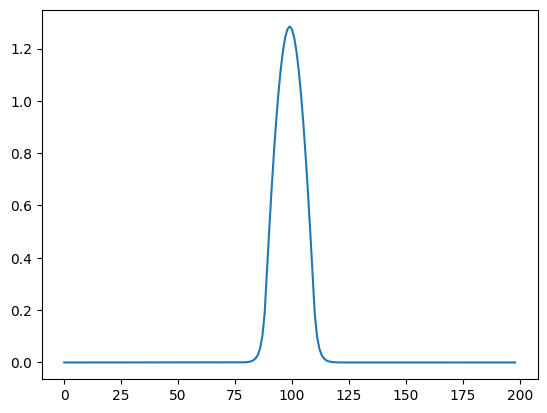

Epoch 4249:
  β² prediction ≈ [118.0075    47.911392  77.76181   25.486622 126.18588   65.14764
  50.217205  59.20901   71.917816 117.54834   47.021652 143.36314
  96.68716  122.882645 295.44833  110.800316 149.86026   48.855885
 259.65344   65.478836 110.92253  110.35867  101.82146  351.66638
  81.59852   44.35012   55.29882  112.94829   75.53671   79.3088
  51.97993   98.70161  130.43042  144.92676  232.23409  340.29645
 158.49214  148.6196   156.89702   94.86558   59.647846 324.88846
  69.70138   90.012375  55.19303  102.41696   34.17961  408.365
 199.36716   61.611034 113.91703  109.55102   60.26373   45.9332
 217.43575  129.8554    48.441265  43.10143  165.3918   226.60959
  28.496117 177.32417  113.48428   81.59722 ]
  β² max ≈ [121.25809   49.95452   81.48002   26.80984  128.96968   67.01926
  52.39259   61.231297  73.86849  122.77931   49.91381  147.84357
  98.99583  125.7287   300.49976  112.909    151.96162   53.636726
 262.11868   68.97797  115.01835  112.6948   105.18776  3

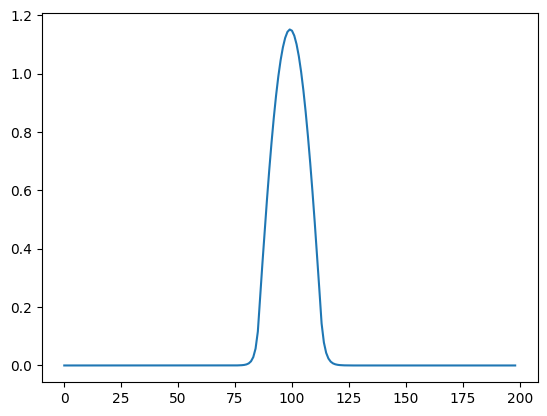

Epoch 5249:
  β² prediction ≈ [ 36.044888 113.42146  194.0452    28.431004 102.97094  149.97429
 128.4566    87.081406 106.2492   418.87692  168.4337   454.92416
  45.61541  115.474945 154.03406  104.97601   25.82204  111.5556
  86.68794  306.6717   409.2849   164.48369  266.4726   204.1256
 149.4051   204.07895   65.1793    46.69144  143.78195  201.23674
  81.46353  267.5051    82.00123  122.0846   220.0104   331.2514
  53.24386  253.03517  254.19914   95.56601   79.52381   24.20966
  39.70849   36.214817 180.95811   46.050686  72.663795 327.3834
 148.77966   54.932766  88.688446  94.05253   33.60555   41.86282
 119.47293  163.81104  225.99399  118.00634  213.12015  205.07709
  47.922356 229.59377  131.21925   35.11407 ]
  β² max ≈ [ 38.031307 116.960304 196.21805   29.603004 107.46993  152.31154
 130.99977   89.451744 112.92272  421.6997   174.37973  458.88263
  49.08618  119.02687  158.03027  109.28064   29.27494  115.88614
  89.2348   309.15802  416.5745   168.66158  274.79178  207

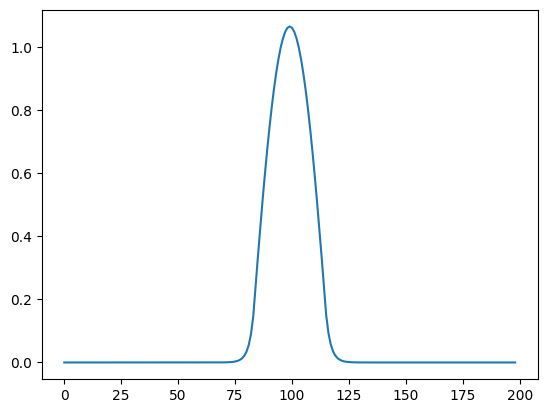

Epoch 6249:
  β² prediction ≈ [225.01523  136.25822  180.86363   32.574265 125.560974 110.66977
 114.84116  119.71587   69.65172  116.63274   67.92954  402.87143
 175.74042   79.48726   26.758268  61.536438 290.33783   69.531746
  35.81003   48.05984  179.0736   155.82718   59.188244 204.1975
  23.471497  20.722118 238.16364   76.31893   66.90149   75.92409
 109.71885   96.00395  143.65375  112.66555  162.44919   32.947407
  45.272102 431.09872  105.65998  194.85413  154.72044  116.732605
 245.13416   48.96473   32.191887 129.69571  114.19026   36.39734
  63.063812 191.4121   198.39516  206.79485  133.99596  140.78671
  81.04085  164.18324  298.07358  107.77416   72.02918   53.57666
 285.431    189.36174  177.44319   84.84522 ]
  β² max ≈ [227.43779  140.36575  185.26979   35.88499  129.2279   114.48561
 119.367935 122.40409   73.381386 121.21153   70.96179  405.37482
 181.60315   82.63614   29.505846  64.427864 293.0892    71.68861
  37.557587  52.063446 182.03134  159.21286   61.5777

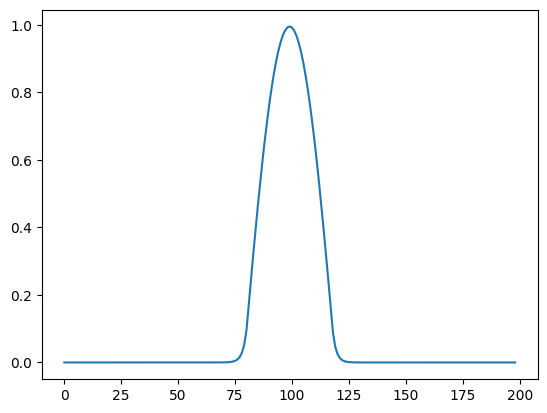

Epoch 7249:
  β² prediction ≈ [306.14383  267.62958  135.32454   37.177967 156.84607  127.5418
  46.916367  82.29993  103.94538   65.20951  135.14339  127.65129
 167.4832   399.51367   87.15686  193.81007  303.80997  193.11398
 115.87552  217.07156  155.7392    58.17928  113.8189   121.12319
 171.08008   34.864944 149.36794  174.77205   69.585106 263.06412
  66.59718  374.0701   162.986    163.48544   33.899265  49.829277
  42.618595  64.56835  124.66515   68.46117   72.814     98.72121
  42.632362  99.264565 144.31506   69.613785 365.07584  144.0112
  39.4937    97.535645 232.02234   75.0207    33.763317 139.70453
 108.49937  118.484276 371.47525  181.60454  206.68193  102.85328
  86.23496  226.37918  323.60422  274.59015 ]
  β² max ≈ [308.71146  272.03067  137.10538   39.61426  159.74371  134.07492
  49.066273  84.50641  105.82287   67.185745 138.60226  130.0171
 170.92314  406.57727   94.78807  196.01414  306.28854  198.73395
 119.42537  223.59785  158.23607   60.069492 117.45954  1

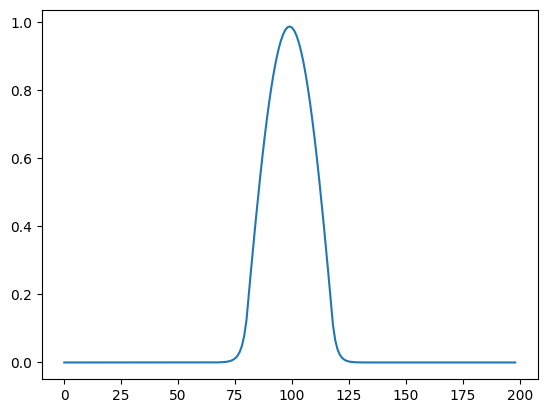

Epoch 8249:
  β² prediction ≈ [184.6404   184.5069   204.21133   91.34908  223.35905  134.4992
  70.68431   52.348824  34.979206 149.36433   50.383095 181.44966
  51.728867 219.14015   36.83787   64.61419  152.97374  123.03025
  52.895283  39.562603 116.20956   74.8261   155.36351  138.79286
  16.321886 119.76639  105.6945    63.168407 178.54303   99.75037
 103.92744  121.531296 387.04117   57.708244  92.21459   26.920395
  57.014923  76.02793  142.60556  176.0154   207.85834  144.92065
  87.76984   38.91794   58.089363 314.99777   37.405106 134.8198
  71.439735 240.30493   50.63074   56.128895 239.34639   54.994755
 170.95616  222.26987  426.41815  118.711784 122.2535   120.18594
  98.90699   25.696203  40.571728  56.663284]
  β² max ≈ [188.98228  190.1882   209.7127    93.66122  226.37794  136.86932
  73.99052   53.886375  37.786854 155.29282   52.489403 187.43129
  52.97197  222.96675   38.452576  66.625946 157.55501  125.51602
  56.305275  41.950832 124.339874  80.35082  159.08939 

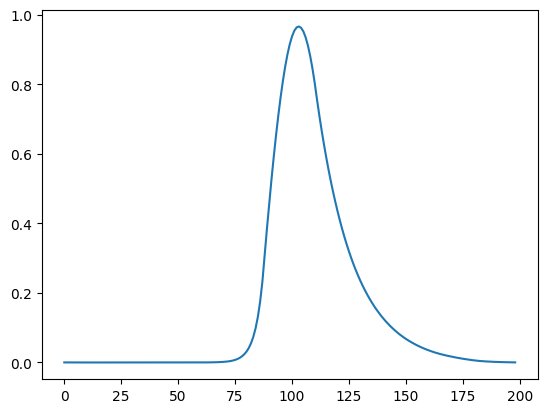

Epoch 9249:
  β² prediction ≈ [ 98.558105 244.38333   81.177086 216.45544   26.043732 142.51118
  57.195095 302.00916  274.2425   119.56983   44.93271   80.332924
 377.52338   69.72697   34.267807 271.79703  274.03296  123.99143
  95.32016  241.71013   54.126736  87.67889  212.18126   61.99639
 131.73091  109.00574   51.33807   45.192413 192.91791  164.42392
 123.43704  130.71535  160.57729  229.2887    99.95973   89.423645
 156.17824  103.795784 293.90164   33.86578   43.387104 100.56606
 163.24794  354.8047   225.04605   82.73287   45.495266 248.47166
 127.22567  174.92056   88.108154  84.60443  211.20659  268.40375
 135.52861   43.883057  79.77287  258.9585   127.28926  124.59103
 206.1106   116.177635 187.00496  152.25162 ]
  β² max ≈ [100.39071  249.44257   88.99435  220.98888   28.357946 147.3035
  59.847557 305.54218  281.16766  121.9329    47.953384  82.71977
 380.30444   75.18516   36.09668  276.3083   279.1168   129.16194
  98.09943  246.0969    59.60788   92.55279  219.21939

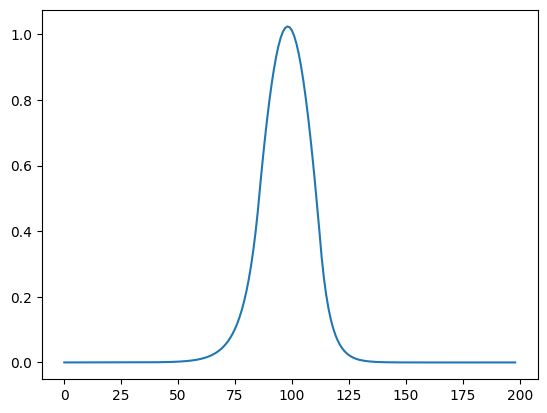

(PINO(
   (backbone): FNO1d(
     (input_proj): Sequential(
       (0): Conv1d(4, 64, kernel_size=(1,), stride=(1,))
       (1): GELU(approximate='none')
       (2): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
     )
     (spectral_blocks): ModuleList(
       (0-3): 4 x SpectralConv1d()
     )
     (pointwise_convs): ModuleList(
       (0-3): 4 x Conv1d(64, 64, kernel_size=(1,), stride=(1,))
     )
     (output_proj): Sequential(
       (0): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
       (1): GELU(approximate='none')
       (2): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
     )
     (activation): GELU(approximate='none')
   )
   (field_head): Sequential(
     (0): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
     (1): GELU(approximate='none')
     (2): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
     (3): GELU(approximate='none')
     (4): Conv1d(64, 1, kernel_size=(1,), stride=(1,))
   )
   (eigenvalue): Sequential(
     (0): AdaptiveAvgPool1d(output_size=1)
     (1): Fl

In [16]:
model, betas_avg, analytical_EIs, train_loss_history, val_loss_history = train(loader, val_loader, model, optimizer, scheduler, epochs=10001, load=False, save=True)

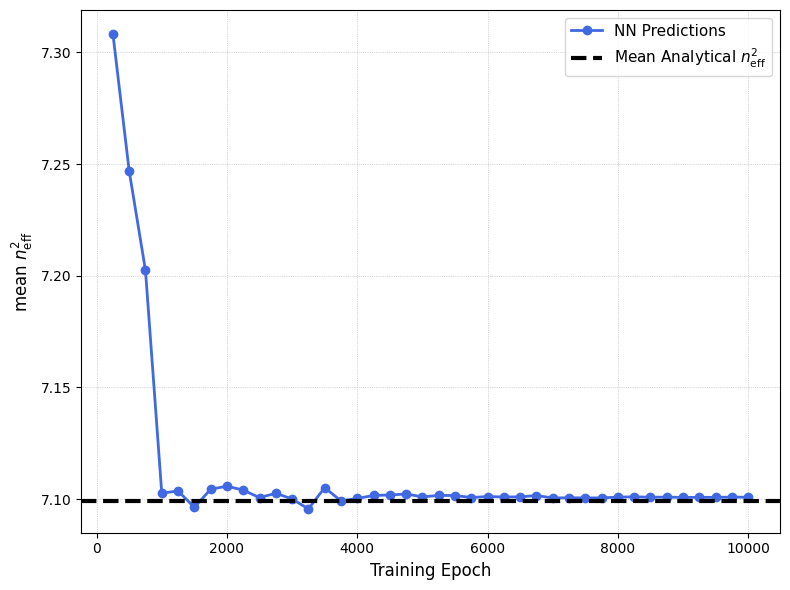

In [18]:
plt.figure(figsize=(8, 6))

# Plot neural network predictions
plt.plot(torch.arange(250, 10001, 250), betas_avg, label='NN Predictions', color='royalblue', linewidth=2, marker='o')

# Plot horizontal line for analytical average
mean_EI = np.mean(analytical_EIs)
plt.axhline(mean_EI, color='black', linestyle='--', linewidth=3, label='Mean Analytical $n_\\mathrm{eff}^2$')

# Styling
plt.xlabel('Training Epoch', fontsize=12)
plt.ylabel(r'mean $n_\mathrm{eff}^2$', fontsize=12)
# plt.title('Comparison of NN Predictions and Analytical Average', fontsize=13)
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

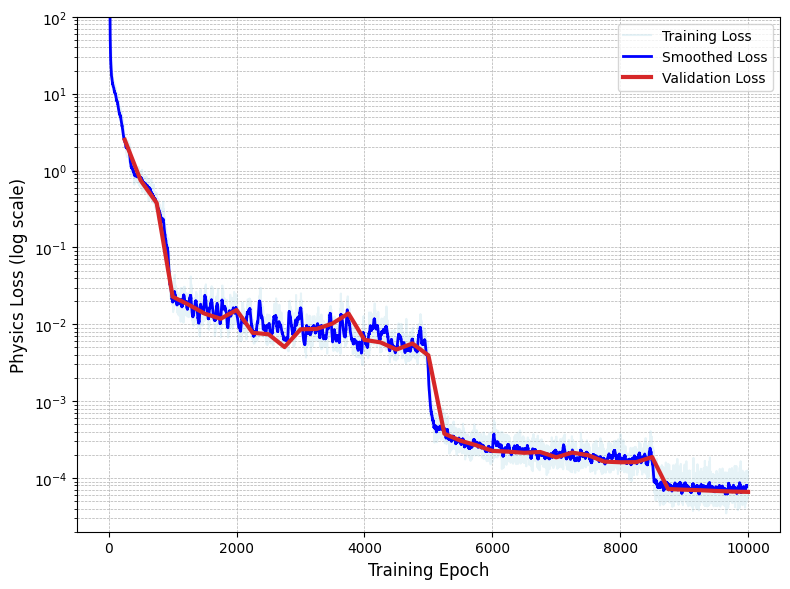

In [24]:
# Compute running average
def running_average(data, window_size=20):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(8, 6))

# Training loss curve
plt.plot(train_loss_history, label='Training Loss', color='lightblue', alpha=0.3)

# Smoothed version
smoothed_loss = running_average(train_loss_history)
plt.plot(smoothed_loss, label='Smoothed Loss', color='blue', linewidth=2)

# Validation loss curve
plt.plot(torch.arange(250, 10001, 250), val_loss_history, label='Validation Loss', color='tab:red', linewidth=3)

# Log scale and grid
plt.yscale('log')
plt.ylim([2e-5, 1e2])
plt.grid(True, which="both", ls="--", lw=0.5)

# Labels and title
plt.xlabel('Training Epoch', fontsize=12)
plt.ylabel('Physics Loss (log scale)', fontsize=12)

# Legend
plt.legend(fontsize=10)

# Tight layout for cleaner figure
plt.tight_layout()

plt.show()

(1,) (1, 199)


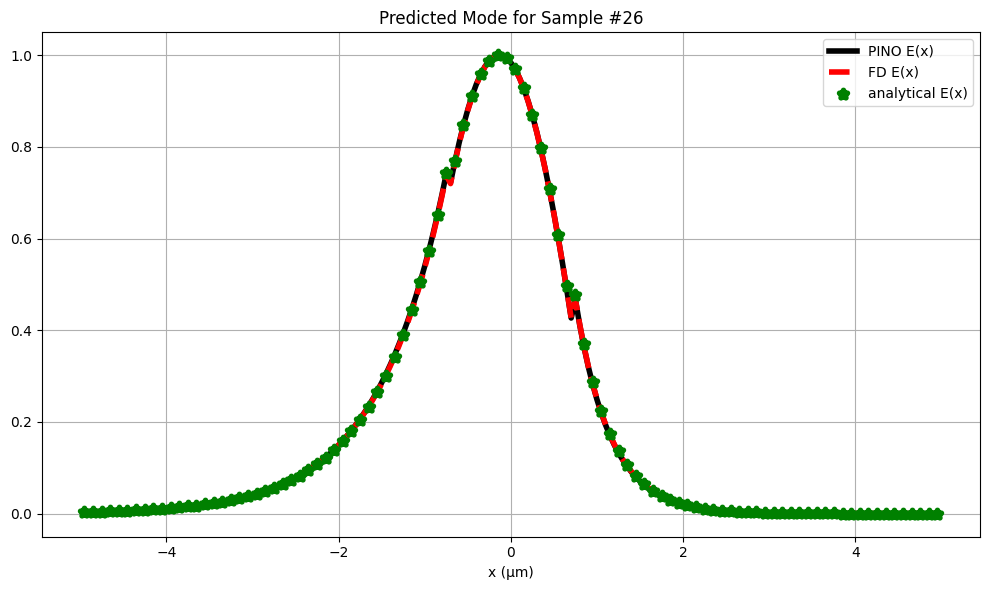

In [25]:
dx = dataset.dx

# Pick a random index from the dataset
random_idx = random.randint(0, len(dataset) - 1)
xyr, features = dataset[random_idx]  # shape: (1, 2, N)
xyr = xyr.unsqueeze(0).to(device)
features = features.unsqueeze(0)
k0 = 2*np.pi / 1.55

with torch.no_grad():
    E_out, beta_nn = model(xyr)       # (N,)
    E_out = E_out.cpu().squeeze()        # (N,)

    n2 = xyr[:, 1:2, :]
    n2_max = features[:, -2]
    n2_min = torch.minimum( features[:, -4],  features[:, -3])  # (B, 1)
    
    x_out = xyr[:, 0:1, :].cpu().squeeze()    # (N,)
    ri_out = xyr[:, 1:2, :].cpu().squeeze()   # (N,)
    
    n_cladding = torch.sqrt(features[0, -4])
    n_substrate = torch.sqrt(features[0, -3])
    n_core= torch.sqrt(features[0, -2])
    w_core= features[0, 1]
    k0 =  features[0, 0].item()
    TE = features[0, -1]

    beta_sq = (n2_max - beta_nn * (n2_max - n2_min)) * k0**2
    
    beta, modes = solve_fd_mode(ri_out.numpy(), dataset.dx, k0=k0, TM=(TE==0), num_modes=1)

    analytical_modes, analytical_EIs = analytical_solution(x_out.numpy(), n_core.item(), n_substrate.item(), n_cladding.item(), w_core.item(), k0, TE==0)
    print(analytical_EIs.shape, analytical_modes.shape)
    if TE==0:
        analytical_modes /= ri_out
        
# Normalize E for visualization
E_out = E_out / (torch.abs(E_out).max())
modes = modes / (np.abs(modes).max())
analytical_modes = analytical_modes / (np.abs(analytical_modes).max())

sign1 = (2 * (np.dot(analytical_modes, E_out.numpy()) > 0) - 1).item()
sign2 = (2 * (np.dot(analytical_modes, modes.T) > 0) - 1).item()

plt.figure(figsize=(10, 6))
plt.plot(x_out, sign1 * E_out, label="PINO E(x)", linewidth=4, color='black')
plt.plot(x_out, sign2 * modes[0], label="FD E(x)", linestyle='dashed', linewidth=4, color='red')
plt.scatter(x_out[::2], analytical_modes[0][::2], label="analytical E(x)", marker='*', linewidth=4, color='green', zorder=2)

plt.legend()
plt.grid()
plt.title(f"Predicted Mode for Sample #{random_idx}")
plt.xlabel("x (μm)")
plt.tight_layout()
plt.show()


In [26]:
dataset = SlabWaveguideDataset(dx = 1/40, stochastic=True, n_dataset=32, x_range=(-5, 5), device=device)

devices_list = [dataset[0] for i in range(4)]
xyr_list = [item[0] for item in devices_list]
features_list = [item[1] for item in devices_list]
for (i, val) in zip(range(4), [0.0, 0.0, 1.0, 1.0]):
    xyr_list[i][-2] = val
    features_list[i][-1] = val

FNO took 0.01561 seconds for the evaluation
FD took 0.01219 seconds for the evaluation
FNO took 0.00444 seconds for the evaluation
FD took 0.01175 seconds for the evaluation
FNO took 0.00449 seconds for the evaluation
FD took 0.01207 seconds for the evaluation
FNO took 0.00577 seconds for the evaluation
FD took 0.01399 seconds for the evaluation


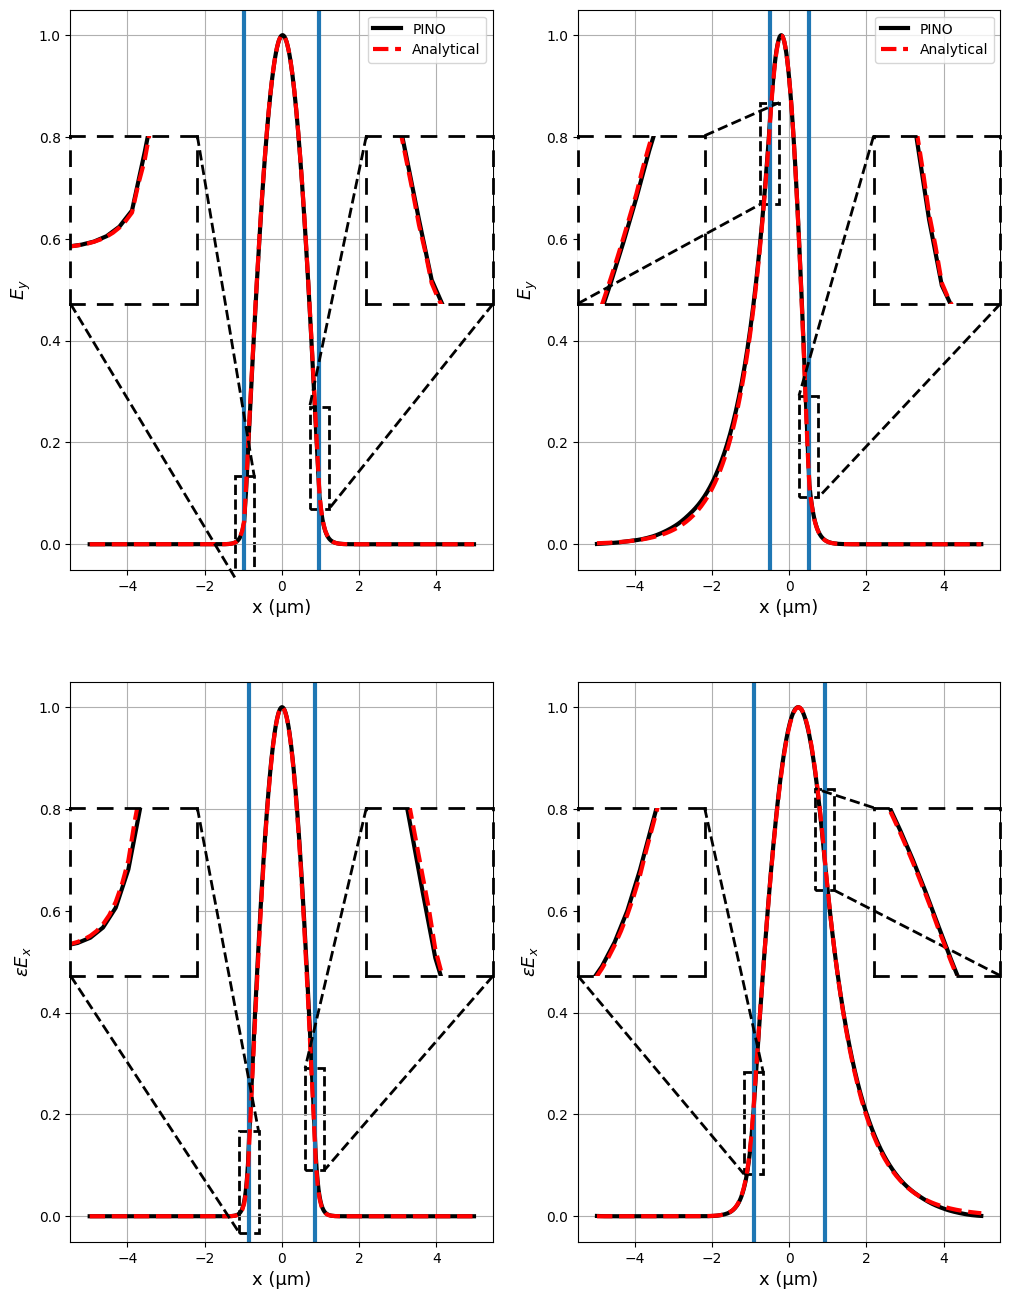

In [27]:
# Set up plot
fig, axs = plt.subplots(2, 2, figsize=(12, 16))
# fig.suptitle("Predicted Modes for 3 Random Slab Waveguides")
for i in range(2):
    for j in range(2):
        xyr, features = xyr_list[2 * i + j], features_list[2 * i + j]
        xyr = xyr.unsqueeze(0).to(device)
        features = features.unsqueeze(0).to(device)
    
        start_time = time.time()
        with torch.no_grad():
            E_out, beta_nn = model(xyr)
            E_out = E_out.cpu().squeeze()
        end_time = time.time()
        print('FNO took', round(end_time - start_time, 5), 'seconds for the evaluation')


        n2 = xyr[:, 1:2, :]
        n2_max = features[:, -2]
        n2_min = torch.minimum(features[:, -4], features[:, -3])

        x_out = xyr[:, 0:1, :].cpu().squeeze()
        ri_out = xyr[:, 1:2, :].cpu().squeeze()

        n_cladding = torch.sqrt(features[0, -4])
        n_substrate = torch.sqrt(features[0, -3])
        n_core = torch.sqrt(features[0, -2])
        w_core = features[0, 1]
        k0 = features[0, 0].item()
        TE = features[0, -1]

        beta_sq = (n2_max - beta_nn * (n2_max - n2_min)) * k0**2

        start_time = time.time()
        beta, modes = solve_fd_mode(ri_out.numpy(), dataset.dx, k0=k0, TM=(TE==0), num_modes=1)
        end_time = time.time()
        print('FD took', round(end_time - start_time, 5), 'seconds for the evaluation')

        analytical_modes, analytical_EIs = analytical_solution(
            x_out.numpy(), n_core.item(), n_substrate.item(), n_cladding.item(), w_core.item(), k0, TE==0
        )
        
        # Normalize for plotting
        if TE == 0:
            E_out = E_out * ri_out
        E_out = E_out / torch.abs(E_out).max()
        modes = modes / np.abs(modes).max()
        analytical_modes = analytical_modes / np.abs(analytical_modes).max()
    
        # Align signs for visual comparison
        sign1 = (2 * (np.dot(analytical_modes[0], E_out.numpy()) > 0) - 1)
        sign2 = (2 * (np.dot(analytical_modes[0], modes[0]) > 0) - 1)
    
        ax = axs[i, j]
        ax.plot(x_out, sign1 * E_out, label="PINO", linewidth=3, color='black')
        ax.axvline(x=w_core.cpu()/2, lw=3, color='tab:blue')
        ax.axvline(x=-w_core.cpu()/2, lw=3, color='tab:blue')
        ax.plot(x_out[::2], analytical_modes[0][::2], linestyle='dashed', linewidth=3, color='red', label="Analytical")
        ax.set_xlabel("x (μm)", fontsize=13)
        ax.set_ylabel("$\epsilon E_x$" if TE==1 else "$E_y$", fontsize=13)
        ax.grid(True)
        if i == 0:
            ax.legend()
            
        # Create an inset zoomed-in axes
        axins = inset_axes(
            ax,
            width="30%", 
            height="30%",
            loc="center left",
            bbox_to_anchor=(0.7, 0.125, 1, 1),  # (x_offset, y_offset, width, height)
            bbox_transform=ax.transAxes,        # interpret bbox in axis fraction coordinates
            borderpad=0                        # no extra padding
        )
        
        axins.plot(x_out[::2], analytical_modes[0][::2], color='black', linewidth=3)  # Plot the same data in the inset
        axins.plot(x_out, sign1 * E_out, color='red', linewidth=3,linestyle='dashed')  # Plot the same data in the inset
        
        analytical_mode_interface_value = analytical_modes[0][torch.abs(x_out-w_core.cpu()/2) < 1/20][0]            
        for spine in axins.spines.values():
          spine.set_linestyle((0, (5, 5)))    # spine.set(linewidth=2)
          spine.set(linewidth=2)
        
        # Define zoom region
        x1, x2, y1, y2 = w_core.cpu()/2 -0.25, w_core.cpu()/2 +0.25, analytical_mode_interface_value-0.1, analytical_mode_interface_value+0.1  # Zoom-in limits
        axins.set_xlim(x1, x2)
        axins.set_ylim(y1, y2)
        
        # Remove ticks on inset
        axins.set_xticks([])
        axins.set_yticks([])
        axins.grid(True);
        
        # Mark zoomed area on the main plot
        mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="black", lw=2, linestyle='dashed')
        
        # Create an inset zoomed-in axes
        axins = inset_axes(
            ax,
            width="30%", 
            height="30%",
            loc="center left",
            bbox_to_anchor=(0.0, 0.125, 1, 1),  # (x_offset, y_offset, width, height)
            bbox_transform=ax.transAxes,        # interpret bbox in axis fraction coordinates
            borderpad=0                        # no extra padding
        )
        
        axins.plot(x_out[::2], analytical_modes[0][::2], color='black', linewidth=3)  # Plot the same data in the inset
        axins.plot(x_out, sign1 * E_out, color='red', linewidth=3,linestyle='dashed')  # Plot the same data in the inset
        
        analytical_mode_interface_value = analytical_modes[0][torch.abs(x_out+w_core.cpu()/2) < 1/20][0]            
        for spine in axins.spines.values():
          spine.set_linestyle((0, (5, 5)))    # spine.set(linewidth=2)
          spine.set(linewidth=2)
        
        # Define zoom region
        x1, x2, y1, y2 = -w_core.cpu()/2 -0.25, -w_core.cpu()/2 +0.25, analytical_mode_interface_value-0.1, analytical_mode_interface_value+0.1  # Zoom-in limits
        axins.set_xlim(x1, x2)
        axins.set_ylim(y1, y2)
        
        # Remove ticks on inset
        axins.set_xticks([])
        axins.set_yticks([])
        axins.grid(True);
        
        # Mark zoomed area on the main plot
        mark_inset(ax, axins, loc1=3, loc2=1, fc="none", ec="black", lw=2, linestyle='dashed')
    
plt.show()

In [23]:
def evaluate_model_errors(model, dataset, device):
    field_errors_pino = []
    field_errors_fd = []
    eigenvalue_errors_pino = []
    eigenvalue_errors_fd = []

    model.eval()
    for idx in range(len(dataset)):
        xyr, features = dataset[idx]
        xyr = xyr.unsqueeze(0).to(device)
        features = features.unsqueeze(0).to(device)
        dx = dataset.dx

        k0 = features[0, 0].item()
        TE = features[0, -1].item()
        n2_max = features[0, -2]
        n2_min = torch.minimum(features[0, -4], features[0, -3])

        with torch.no_grad():
            E_out, beta_nn = model(xyr)
        E_out = E_out.squeeze().cpu().numpy()
        x_out = xyr[:, 0, :].squeeze().cpu().numpy()
        ri_out = xyr[:, 1, :].squeeze().cpu().numpy()

        beta_sq = (n2_max - beta_nn * (n2_max - n2_min)) * k0**2
        beta_pino = torch.sqrt(beta_sq).item()

        # Solve FD
        beta_fd, modes_fd = solve_fd_mode(ri_out, dx, k0, TM=(TE == 0), num_modes=1)
        mode_fd = modes_fd[0]

        # Analytical
        n_clad = torch.sqrt(features[0, -4]).item()
        n_subs = torch.sqrt(features[0, -3]).item()
        n_core = torch.sqrt(features[0, -2]).item()
        w_core = features[0, 1].item()
        analytical_modes, analytical_EIs = analytical_solution(x_out, n_core, n_subs, n_clad, w_core, k0, TE==0)
        mode_ana = analytical_modes[0]
        beta_ana = analytical_EIs[0] * k0

        # Normalize fields
        E_out /= np.linalg.norm(E_out)
        mode_fd /= np.linalg.norm(mode_fd)
        if TE == 0:
            mode_ana = mode_ana / ri_out
        mode_ana /= np.linalg.norm(mode_ana)

        # Fix signs
        sign_pino = np.sign(np.dot(E_out, mode_ana))
        sign_fd = np.sign(np.dot(mode_fd, mode_ana))
        E_out *= sign_pino
        mode_fd *= sign_fd

        # Errors
        err_pino = 100 * np.linalg.norm(E_out - mode_ana) / np.linalg.norm(mode_ana)
        err_fd = 100 * np.linalg.norm(mode_fd - mode_ana) / np.linalg.norm(mode_ana)
        
        field_errors_pino.append(err_pino)
        field_errors_fd.append(err_fd)

        eigenvalue_errors_pino.append(np.abs((beta_pino - beta_ana) / beta_ana))
        eigenvalue_errors_fd.append(np.abs((beta_fd - beta_ana) / beta_ana))

    return {
        "field_error_pino": np.mean(field_errors_pino),
        "field_error_fd": np.mean(field_errors_fd),
        "eigen_error_pino": np.mean(eigenvalue_errors_pino),
        "eigen_error_fd": np.mean(eigenvalue_errors_fd),
    }


In [ ]:
start_time = time.time()
errors = evaluate_model_errors(model, val_ds, device)
end_time = time.time()
print('this took', end_time - start_time, 'seconds')
print("PINO Field Error (relative L2):", errors["field_error_pino"])
print("FD Field Error (relative L2):", errors["field_error_fd"])
print("PINO Eigenvalue Error (avg rel):", errors["eigen_error_pino"])
print("FD Eigenvalue Error (avg rel):", errors["eigen_error_fd"])